# Color & Illumination Normalization (Preprocess)

**ปรับความคงที่ของสีและแสง** เพื่อเตรียมข้อมูลสำหรับเทรนโมเดลความสดของเนื้อวัว

**Pipeline ที่ใช้ (เวอร์ชัน tuned & improved):**
- **Gaussian Filtering (เพิ่มใหม่):** ลดสัญญาณรบกวนและแสงสะท้อนจ้า (Glare) บนบรรจุภัณฑ์พลาสติก
- **Soft Gray World White Balance:** ปรับสมดุลสีแบบ “ไม่แรงเกิน” 
- **CLAHE บนช่อง L (LAB):** ทำ illumination normalization อย่างนุ่มนวล

> เป้าหมาย: ลดผลกระทบจากสภาพแสง/สีที่ต่างกัน แต่ยังคง “สีแดงของเนื้อ” ซึ่งเป็นสัญญาณสำคัญในการจำแนกความสด

## 1. Imports & Global Setup (ตั้งค่า Path ที่นี่ที่เดียว)

In [6]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
from tqdm import tqdm
import random

%matplotlib inline

# ==========================================
# 🛑 ระบุ Path ของโฟลเดอร์ Dataset ที่นี่ที่เดียว 🛑
# ==========================================
BASE_DATASET_PATH = r"C:\Users\user\Documents\work\medfund\Project_SE_for_AI\datasets\Beef Freshness.v6-dataset-beef-v2.folder\train"

# ตรวจสอบว่า Path มีอยู่จริงหรือไม่
dataset_dir = Path(BASE_DATASET_PATH)
if not dataset_dir.exists():
    print(f"❌ ไม่พบโฟลเดอร์: {dataset_dir}")
else:
    print(f"✅ เชื่อมต่อโฟลเดอร์สำเร็จ: {dataset_dir}")

✅ เชื่อมต่อโฟลเดอร์สำเร็จ: C:\Users\user\Documents\work\medfund\Project_SE_for_AI\datasets\Beef Freshness.v6-dataset-beef-v2.folder\train


## 2. Core Normalization Functions

In [7]:
def soft_gray_world_white_balance(rgb: np.ndarray, alpha: float = 0.25) -> np.ndarray:
    """ Soft Gray-World White Balance """
    img = rgb.astype(np.float32)
    mean = img.mean(axis=(0, 1))               
    gray_mean = mean.mean()
    full_scale = gray_mean / (mean + 1e-6)     
    scale = 1.0 + alpha * (full_scale - 1.0)
    out = img * scale
    return np.clip(out, 0, 255).astype(np.uint8)

def clahe_on_l_channel(rgb: np.ndarray, clip_limit: float = 1.2, tile_grid_size=(8, 8)) -> np.ndarray:
    """ CLAHE on LAB L-channel """
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def preprocess_color_illumination_tuned(
    rgb: np.ndarray,
    use_blur: bool = True,       
    blur_ksize: tuple = (5, 5),  
    use_soft_wb: bool = True,
    wb_alpha: float = 0.25,
    use_clahe: bool = True,
    clahe_clip: float = 1.2
) -> np.ndarray:
    out = rgb
    if use_blur:
        out = cv2.GaussianBlur(out, blur_ksize, 0)
    if use_soft_wb:
        out = soft_gray_world_white_balance(out, alpha=wb_alpha)
    if use_clahe:
        out = clahe_on_l_channel(out, clip_limit=clahe_clip)
    return out

ใช้ภาพทดสอบจาก: C:\Users\user\Documents\work\medfund\Project_SE_for_AI\datasets\Beef Freshness.v6-dataset-beef-v2.folder\train\Fresh\FRESH-1-_JPG_jpg.rf.35ee26c0fed539cb36e5d2f523856381.jpg


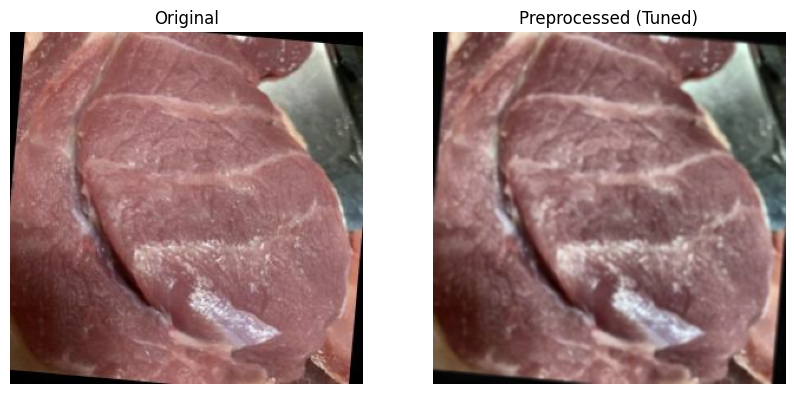

In [8]:
# ดึงภาพ .jpg ภาพแรกที่เจอใน Dataset มาใช้เป็นภาพทดสอบ
all_images = list(dataset_dir.rglob("*.jpg"))
if not all_images:
    raise FileNotFoundError("ไม่พบไฟล์ .jpg ในโฟลเดอร์ที่ระบุ")

sample_img_path = str(all_images[0])
print(f"ใช้ภาพทดสอบจาก: {sample_img_path}")

bgr = cv2.imread(sample_img_path)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

rgb_prep = preprocess_color_illumination_tuned(
    rgb,
    use_blur=True,       
    use_soft_wb=True,
    wb_alpha=0.25,       
    use_clahe=True,
    clahe_clip=1.2       
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rgb);      axs[0].set_title("Original")
axs[1].imshow(rgb_prep); axs[1].set_title("Preprocessed (Tuned)")
for ax in axs: ax.axis("off")
plt.show()

=== R-channel stats (Before) ===
R_mean: 141.68
R_std: 46.10
R_min: 0
R_max: 255
R_p5: 40.00
R_p50: 154.00
R_p95: 196.00

=== R-channel stats (After) ===
R_mean: 136.56
R_std: 45.43
R_min: 0
R_max: 252
R_p5: 51.00
R_p50: 143.00
R_p95: 202.00


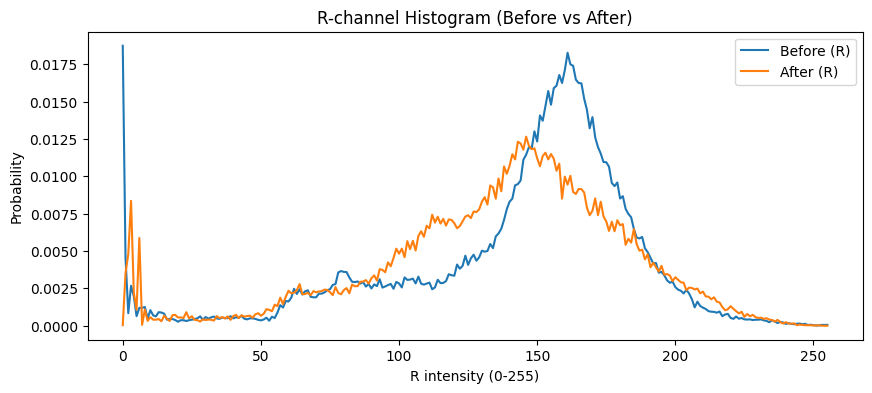

R median drop (before - after) = 11.00
✅ Looks OK: R-channel preserved reasonably


In [9]:
def r_channel_hist_and_stats(rgb: np.ndarray, bins: int = 256):
    R = rgb[:, :, 0].astype(np.uint8)
    hist = cv2.calcHist([R], [0], None, [bins], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-9)  
    stats = {
        "R_mean": float(R.mean()), "R_std": float(R.std()),
        "R_min": int(R.min()), "R_max": int(R.max()),
        "R_p5": float(np.percentile(R, 5)),
        "R_p50": float(np.percentile(R, 50)),
        "R_p95": float(np.percentile(R, 95)),
    }
    return hist, stats

hist_before, stats_before = r_channel_hist_and_stats(rgb)
hist_after,  stats_after  = r_channel_hist_and_stats(rgb_prep)

print("=== R-channel stats (Before) ===")
for k, v in stats_before.items(): print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

print("\n=== R-channel stats (After) ===")
for k, v in stats_after.items(): print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

x = np.arange(256)
plt.figure(figsize=(10,4))
plt.plot(x, hist_before, label="Before (R)")
plt.plot(x, hist_after,  label="After (R)")
plt.title("R-channel Histogram (Before vs After)")
plt.xlabel("R intensity (0-255)")
plt.ylabel("Probability")
plt.legend()
plt.show()

drop = stats_before["R_p50"] - stats_after["R_p50"]
print(f"R median drop (before - after) = {drop:.2f}")

if drop > 15:
    print("⚠️ Warning: R-channel median dropped a lot -> อาจซีดเกินไป (ลด wb_alpha หรือปิด WB)")
else:
    print("✅ Looks OK: R-channel preserved reasonably")

## 3. Batch Processing (ประมวลผลทั้งโฟลเดอร์)

In [10]:
def r_median(rgb: np.ndarray) -> float:
    return float(np.percentile(rgb[:, :, 0].astype(np.uint8), 50))

def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path))
    if bgr is None: raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

WB_ALPHA = 0.25
CLAHE_CLIP = 1.2
USE_BLUR = True

EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rows = []
errors = []

# ใช้ dataset_dir ที่ตั้งไว้ในเซลล์แรกสุด
for class_dir in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
    label = class_dir.name
    img_paths = [p for p in class_dir.rglob("*") if p.suffix.lower() in EXTS]

    for p in img_paths:
        try:
            rgb = read_rgb(p)
            before = r_median(rgb)
            rgb_prep = preprocess_color_illumination_tuned(
                rgb, use_blur=USE_BLUR, use_soft_wb=True, wb_alpha=WB_ALPHA, use_clahe=True, clahe_clip=CLAHE_CLIP
            )
            after = r_median(rgb_prep)
            rows.append({
                "path": str(p), "class": label,
                "R_p50_before": before, "R_p50_after": after, "R_p50_drop": before - after
            })
        except Exception as e:
            errors.append({"path": str(p), "class": label, "error": str(e)})

df = pd.DataFrame(rows)
df_err = pd.DataFrame(errors)

print("Images processed:", len(df))
print("Errors:", len(df_err))
df.head()

Images processed: 3172
Errors: 0


,path,class,R_p50_before,R_p50_after,R_p50_drop
0,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,154.0,143.0,11.0
1,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,154.0,141.0,13.0
2,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,156.0,142.0,14.0
3,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,155.0,143.0,12.0
4,C:\Users\user\Documents\work\medfund\Project_S...,Fresh,140.0,135.0,5.0


         class        level_1   R_p50_drop       n  mean_drop  median_drop  \
0        Fresh              n  1208.000000     NaN        NaN          NaN   
1        Fresh      mean_drop     7.078642     NaN        NaN          NaN   
2        Fresh    median_drop     7.000000     NaN        NaN          NaN   
3        Fresh       p95_drop    13.000000     NaN        NaN          NaN   
4        Fresh  pct_drop_gt15     1.655629     NaN        NaN          NaN   
5        Fresh  pct_drop_gt20     0.000000     NaN        NaN          NaN   
6   Half-Fresh              n  1100.000000     NaN        NaN          NaN   
7   Half-Fresh      mean_drop     5.237273     NaN        NaN          NaN   
8   Half-Fresh    median_drop     5.000000     NaN        NaN          NaN   
9   Half-Fresh       p95_drop    12.000000     NaN        NaN          NaN   
10  Half-Fresh  pct_drop_gt15     0.363636     NaN        NaN          NaN   
11  Half-Fresh  pct_drop_gt20     0.000000     NaN        NaN   

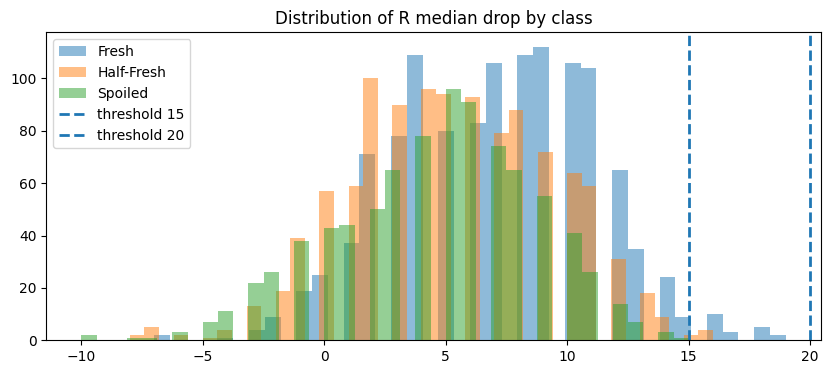

In [11]:
def summarize(group: pd.Series):
    return pd.Series({
        "n": group.count(), "mean_drop": group.mean(), "median_drop": group.median(),
        "p95_drop": group.quantile(0.95), "pct_drop_gt15": (group > 15).mean() * 100,
        "pct_drop_gt20": (group > 20).mean() * 100
    })

summary_by_class = df.groupby("class")["R_p50_drop"].apply(summarize).reset_index()
summary_all = summarize(df["R_p50_drop"]).to_frame().T
summary_all.insert(0, "class", "ALL")
print(pd.concat([summary_by_class, summary_all], ignore_index=True))

plt.figure(figsize=(10,4))
for cls, g in df.groupby("class"): plt.hist(g["R_p50_drop"], bins=40, alpha=0.5, label=cls)
plt.axvline(15, linestyle="--", linewidth=2, label="threshold 15")
plt.axvline(20, linestyle="--", linewidth=2, label="threshold 20")
plt.title("Distribution of R median drop by class")
plt.legend()
plt.show()

## 4. Image Quality Gate (Data Validation)

In [12]:
@dataclass
class QualityResult:
    passed: bool
    reasons: List[str]
    metrics: Dict[str, Any]

def variance_of_laplacian(gray: np.ndarray) -> float:
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def brightness_contrast_lab(rgb: np.ndarray) -> Tuple[float, float]:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L = lab[:, :, 0]
    return float(np.mean(L)), float(np.std(L))

def image_quality_gate(
    rgb: np.ndarray,
    min_width: int = 224, min_height: int = 224,
    blur_thresh: float = 100.0,      
    brightness_low: float = 50.0,    
    brightness_high: float = 220.0,  
    contrast_low: float = 20.0       
) -> QualityResult:
    reasons: List[str] = []
    h, w = rgb.shape[:2]

    if w < min_width or h < min_height: reasons.append(f"resolution_too_small ({w}x{h})")

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    blur_score = variance_of_laplacian(gray)
    if blur_score < blur_thresh: reasons.append(f"image_blurry ({blur_score:.1f})")

    L_mean, L_std = brightness_contrast_lab(rgb)
    if L_mean < brightness_low: reasons.append(f"too_dark ({L_mean:.1f})")
    if L_mean > brightness_high: reasons.append(f"too_bright ({L_mean:.1f})")
    if L_std < contrast_low: reasons.append(f"low_contrast ({L_std:.1f})")

    passed = (len(reasons) == 0)
    return QualityResult(passed=passed, reasons=reasons, metrics={"width": w, "height": h, "blur": blur_score, "L_mean": L_mean, "L_std": L_std})

100%|██████████| 3172/3172 [00:04<00:00, 695.37it/s]


Total: 3172 | Passed: 3115 | Rejected: 57 | Pass rate: 0.982
Top reasons: [('image_blurry', 57)]

สุ่มตัวอย่างภาพที่ถูก Reject (จากทั้งหมด 57 ภาพ):


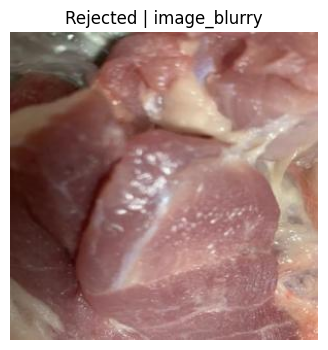

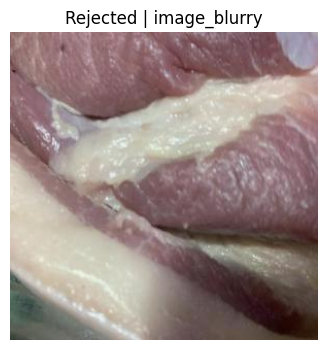

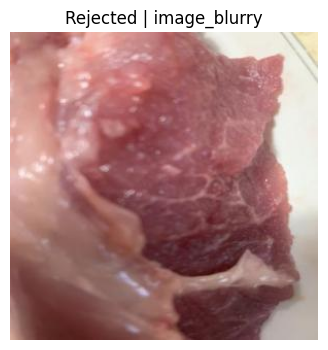

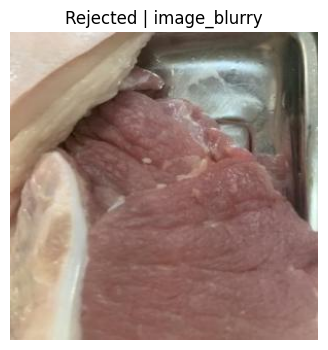

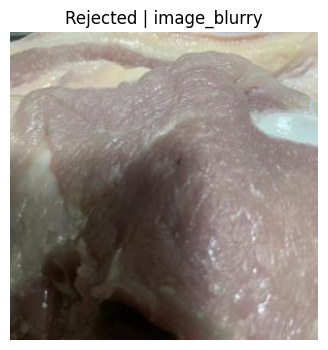

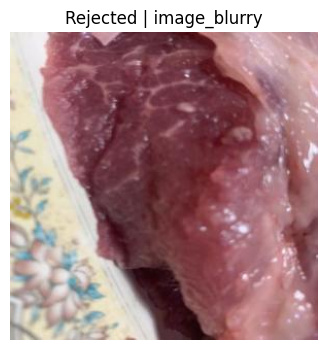

In [13]:
from collections import Counter, defaultdict

# ใช้ dataset_dir (จาก Cell แรกสุด) แทน TRAIN_DIR
paths = [p for p in dataset_dir.rglob("*") if p.suffix.lower() in EXTS]

reasons_counter = Counter()
class_stats = defaultdict(lambda: {"total": 0, "passed": 0})
total = 0
passed = 0

for p in tqdm(paths):
    bgr = cv2.imread(str(p))
    if bgr is None: continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    cls = p.parent.name
    q = image_quality_gate(rgb)

    total += 1
    class_stats[cls]["total"] += 1

    if q.passed:
        passed += 1
        class_stats[cls]["passed"] += 1
    else:
        for r in q.reasons: reasons_counter[r.split(" ")[0]] += 1

print(f"Total: {total} | Passed: {passed} | Rejected: {total-passed} | Pass rate: {passed/total:.3f}")
print("Top reasons:", reasons_counter.most_common(10))

# --- โชว์ภาพที่โดน Reject แบบสุ่ม ---
rejected = []
for p in paths:
    bgr = cv2.imread(str(p))
    if bgr is None: continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    q = image_quality_gate(rgb)
    if not q.passed: rejected.append((str(p), q.reasons))

if rejected:
    print(f"\nสุ่มตัวอย่างภาพที่ถูก Reject (จากทั้งหมด {len(rejected)} ภาพ):")
    for path, reasons in random.sample(rejected, k=min(6, len(rejected))):
        rgb = read_rgb(Path(path))
        plt.figure(figsize=(4,4))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title("Rejected | " + ", ".join([r.split(" ")[0] for r in reasons]))
        plt.show()